In [1]:

import os
import cv2
import numpy as np
import pandas as pd
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def extract_features(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    features = {}
    
    # Color features (9 features)
    for i, color in enumerate(['blue', 'green', 'red']):
        channel = img[:,:,i]
        features[f'{color}_mean'] = np.mean(channel)
        features[f'{color}_std'] = np.std(channel)
        features[f'{color}_median'] = np.median(channel)
    
    
    
   
    
   
    
    return features

In [3]:
# 2. Process all images
def process_dataset(root_dir):
    classes = ['Normal_Sperm', 'Abnormal_Sperm', 'Non-Sperm']
    features = []
    labels = []
    
    for class_idx, class_name in enumerate(classes):
        class_dir = os.path.join(root_dir, class_name)
        if not os.path.exists(class_dir):
            continue
            
        for img_file in os.listdir(class_dir):
            if img_file.lower().endswith(('.png', '.jpg', '.bmp')):
                img_path = os.path.join(class_dir, img_file)
                try:
                    feats = extract_features(img_path)
                    features.append(feats)
                    labels.append(class_idx)
                except Exception as e:
                    print(f"Error processing {img_path}: {str(e)}")
    
    return pd.DataFrame(features), np.array(labels)

In [4]:
# 3. Load and prepare data
print("Processing dataset...")
X, y = process_dataset('data')
print(f"Loaded {len(X)} samples with {len(X.columns)} features")


Processing dataset...
Loaded 3000 samples with 9 features


In [5]:
# 4. Preprocessing
X = pd.get_dummies(X)  # Handle categoricals if any
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [6]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
# 5. Base Classifier (KNN)
print("\n=== Base Classifier (KNN) ===")
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Abnormal', 'Non-Sperm']))


=== Base Classifier (KNN) ===
              precision    recall  f1-score   support

      Normal       0.51      0.63      0.57       204
    Abnormal       0.53      0.53      0.53       201
   Non-Sperm       0.84      0.64      0.72       195

    accuracy                           0.60       600
   macro avg       0.63      0.60      0.61       600
weighted avg       0.63      0.60      0.61       600



In [8]:
# 6. Advanced Classifiers with Hyperparameter Tuning

## Random Forest
print("\n=== Random Forest (Optimized) ===")
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
rf = GridSearchCV(RandomForestClassifier(), rf_params, cv=5, n_jobs=-1)
rf.fit(X_train, y_train)
print(f"Best params: {rf.best_params_}")
y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))



=== Random Forest (Optimized) ===


Best params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.61      0.59      0.60       204
           1       0.60      0.61      0.61       201
           2       0.74      0.74      0.74       195

    accuracy                           0.65       600
   macro avg       0.65      0.65      0.65       600
weighted avg       0.65      0.65      0.65       600



In [9]:
## SVM
print("\n=== SVM (Optimized) ===")
svm_params = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf', 'linear']
}
svm = GridSearchCV(SVC(), svm_params, cv=3, n_jobs=-1)
svm.fit(X_train, y_train)
print(f"Best params: {svm.best_params_}")
y_pred_svm = svm.predict(X_test)
print(classification_report(y_test, y_pred_svm))


=== SVM (Optimized) ===
Best params: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
              precision    recall  f1-score   support

           0       0.56      0.61      0.58       204
           1       0.56      0.55      0.55       201
           2       0.80      0.74      0.77       195

    accuracy                           0.63       600
   macro avg       0.64      0.63      0.64       600
weighted avg       0.64      0.63      0.63       600



In [10]:
# 7. Visualization
def plot_results(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Normal', 'Abnormal', 'Non-Sperm'],
                yticklabels=['Normal', 'Abnormal', 'Non-Sperm'])
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()


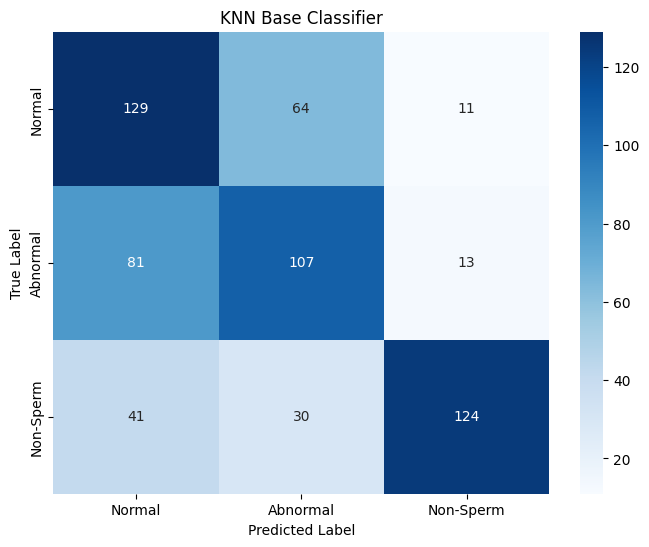

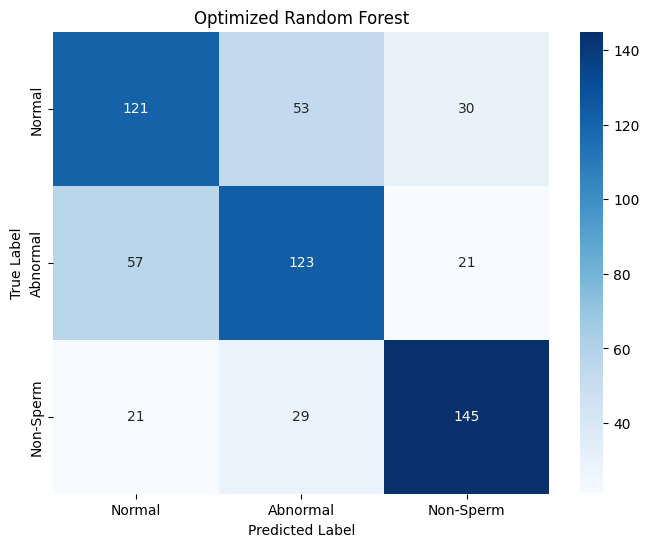

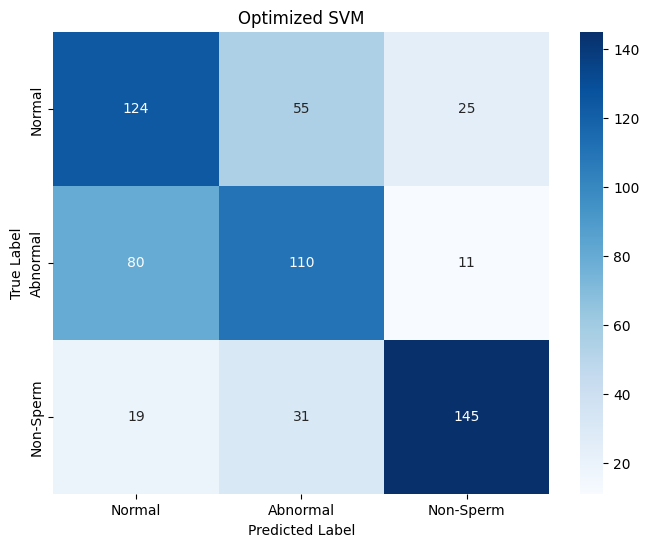

In [11]:
plot_results(y_test, y_pred, "KNN Base Classifier")
plot_results(y_test, y_pred_rf, "Optimized Random Forest")
plot_results(y_test, y_pred_svm, "Optimized SVM")

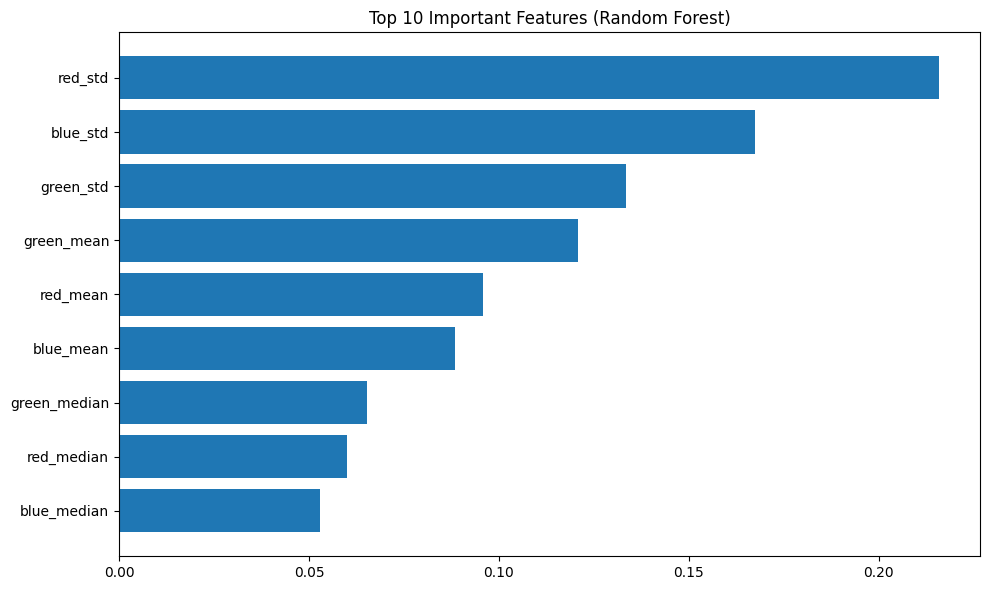

In [12]:
# 8. Feature Importance Analysis
plt.figure(figsize=(10, 6))
importances = rf.best_estimator_.feature_importances_
sorted_idx = np.argsort(importances)[-10:]  # Top 10 features
plt.barh(range(len(sorted_idx)), importances[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(X.columns)[sorted_idx])
plt.title("Top 10 Important Features (Random Forest)")
plt.tight_layout()
plt.show()